# Linear Regression trong bài toán hồi quy

## 1. Chuẩn bị dữ liệu

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import random

def get_column(data, index):
    result = [row[index] for row in data]
    return result

def prepare_data(file_name_dataset):
    data = np.genfromtxt(file_name_dataset, delimiter=',', skip_header=1).tolist()
    N = len(data)

    # Get tv (index=0)
    tv_data = get_column(data, 0)

    # Get radio (index=1)
    radio_data = get_column(data, 1)

    # Get newspaper (index=2)
    newspaper_data = get_column(data, 2)

    # Get sales (index=3)
    sales_data = get_column(data, 3)

    # Buiding X input and y output for training
    X = [tv_data, radio_data, newspaper_data]
    y = sales_data
    return X, y

## 2. Huấn luyện mô hình

In [59]:
def initialize_params():
    # w1 = random.gauss(mu=0.0, sigma=0.01)
    # w2 = random.gauss(mu=0.0, sigma=0.01)
    # w3 = random.gauss(mu=0.0, sigma=0.01)
    # b = 0

    w1, w2, w3, b = (0.016992259082509283, 0.0070783670518262355, -0.002307860847821344, 0)
    return w1, w2, w3, b

In [60]:
def predict(x1, x2, x3, w1, w2, w3, b):
    result = w1*x1 + w2*x2 + w3*x3 + b
    return result

In [61]:
def compute_loss(y_hat, y):
    result = (y_hat - y)**2
    return result

In [62]:
def compute_gradient_wi(xi, y, y_hat):
    # Tính đạo hàm của hàm loss theo wi
    dl_dwi = 2 * (y_hat - y) * xi
    return dl_dwi

def compute_gradient_b(y, y_hat):
    # Tính đạo hàm của hàm loss theo b
    dl_db = 2 * (y_hat - y)
    return dl_db

In [63]:
def update_weight_wi(wi, dl_dwi, lr):
    wi = wi - lr * dl_dwi
    return wi

def update_weight_b(b, dl_db, lr):
    b = b - lr * dl_db
    return b

In [64]:
def implement_linear_regression(X_data, y_data, epoch_max=50, lr=1e-5):
    losses = []

    w1, w2, w3, b = initialize_params()

    N = len(y_data)
    for epoch in range(epoch_max):
        for i in range(N):
            # Get a sample
            x1 = X_data[0][i]
            x2 = X_data[1][i]
            x3 = X_data[2][i]

            y = y_data[i]

            # print(y)
            # Compute output
            y_hat = predict(x1, x2, x3, w1, w2, w3, b)
            # Compute loss
            loss = compute_loss(y_hat, y)

            # Compute gradient w1, w2, w3, b
            dl_dw1 = compute_gradient_wi(x1, y, y_hat)
            dl_dw2 = compute_gradient_wi(x2, y, y_hat)
            dl_dw3 = compute_gradient_wi(x3, y, y_hat)
            dl_db = compute_gradient_b(y, y_hat)

            # Update parameters
            w1 = update_weight_wi(w1, dl_dw1, lr)
            w2 = update_weight_wi(w2, dl_dw2, lr)
            w3 = update_weight_wi(w3, dl_dw3, lr)
            b = update_weight_b(b, dl_db, lr)

            # Logging
            losses.append(loss)
    return (w1, w2, w3, b, losses)

[326.9667843262905, 16.813661135067065, 53.03153479688057, 9.097721194637154, 3.6424308051668244, 7.563752860234681, 22.66109565599889, 0.2903595791172754, 14.838547485180843, 24.076309414072263, 40.37629497003938, 5.1268803606027795, 13.518222414308081, 29.260234447005313, 6.298237914505083, 9.162549922566846, 0.026579461634628335, 26.706667137444764, 31.588025437397253, 7.299166664675038, 4.87832661040257, 0.06589490698448672, 4.659432930180689, 8.197887498801554, 10.726801676543044, 46.88850553057548, 37.00183951157569, 7.945648850356329, 13.192456099944478, 12.99508446043089, 3.692858118961234, 8.94362747789156, 30.181447411539107, 11.431671284831852, 36.174366413011626, 7.460278650398524, 86.65149410437682, 5.3701391264310505, 5.3518169904114785, 46.336728755672745, 2.5374346878656464, 1.4161484943898264, 6.706004362616138, 15.295560375546378, 9.923480328914641, 0.04638468028698762, 1.7385993721560624, 1.6392488216093404, 9.405606514050849, 5.91762067788424, 0.22728553410458135, 7

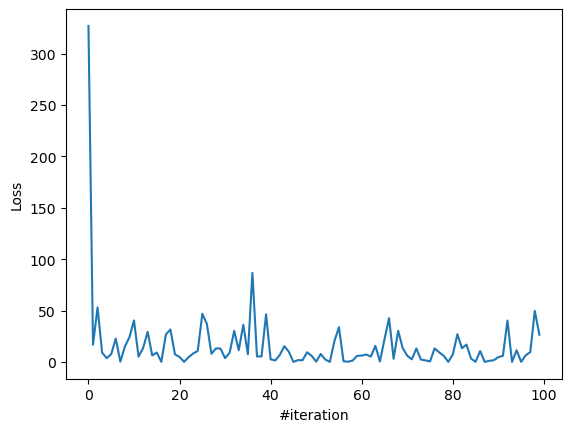

In [65]:
X, y = prepare_data("./data/advertising.csv")
(w1, w2, w3, b, losses) = implement_linear_regression(X, y)
print(losses[0:100])
plt.plot(losses[0:100])
plt.xlabel("#iteration")
plt.ylabel("Loss")
plt.show()

## 3. Chuẩn hóa đặc trưng

### 3.1. Min-Max Scaling

In [66]:
def min_max_scaling(X):
    mins = []
    maxs = []
    X_scaled = []

    # Tìm min và max cho từng feature
    for feature in X:
        min_val = min(feature)
        max_val = max(feature)
        mins.append(min_val)
        maxs.append(max_val)

        # Scale từng phần tử
        scaled_feature = []
        for x in feature:
            scaled_x = (x - min_val) / (max_val - min_val)
            scaled_feature.append(scaled_x)

        X_scaled.append(scaled_feature)

    return X_scaled, mins, maxs

### 3.2. Inverse Min-Max Scaling

In [67]:
def inverse_min_max_scaling(X_scaled, mins, maxs):
    X_recovered = []

    for i in range(len(X_scaled)):
        feature = X_scaled[i]
        min_val = mins[i]
        max_val = maxs[i]

        recovered_feature = []
        for x in feature:
            original_x = x * (max_val - min_val) + min_val
            recovered_feature.append(original_x)

        X_recovered.append(recovered_feature)

    return X_recovered

### 3.3. Z-score Scaling (Standardization)

In [68]:
def z_score_scaling(X):
    means = []
    stds = []
    X_scaled = []

    for feature in X:
        mean_val = sum(feature) / len(feature)
        means.append(mean_val)

        std_val = (sum((x - mean_val) ** 2 for x in feature) / (len(feature) - 1)) ** 0.5

        stds.append(std_val)

        scaled_feature = []
        for x in feature:
            scaled_x = (x - mean_val) / std_val
            scaled_feature.append(scaled_x)

        X_scaled.append(scaled_feature)

    return X_scaled, means, stds

### 3.4. Inverse Z-score Scaling

In [69]:
def inverse_z_score_scaling(X_scaled, means, stds):
    X_recoverd = []

    for i in range(len(X_scaled)):
        feature = X_scaled[i]
        mean_val = means[i]
        std_val = stds[i]

        recovered_feature = []
        for x in feature:
            original_x = x * std_val + mean_val
            recovered_feature.append(original_x)

        X_recoverd.append(recovered_feature)

    return X_recoverd

In [70]:
data1 = [1, 2, 3]
data2 = [4, 5, 6]
data3 = [7, 8, 9]
X = [data1, data2, data3]

# Min-Max
X_minmax, mins, maxs = min_max_scaling(X)
print("Min-Max Scaled:", X_minmax)
print("Recovered Min-Max", inverse_min_max_scaling(X_minmax, mins, maxs))

# Z-score
X_zscore, means, stds = z_score_scaling(X)
print("\nZ-score Scaled:", X_zscore)
print("Recovered Z-Score:", inverse_z_score_scaling(X_zscore, means, stds))

Min-Max Scaled: [[0.0, 0.5, 1.0], [0.0, 0.5, 1.0], [0.0, 0.5, 1.0]]
Recovered Min-Max [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]

Z-score Scaled: [[-1.0, 0.0, 1.0], [-1.0, 0.0, 1.0], [-1.0, 0.0, 1.0]]
Recovered Z-Score: [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]


# Xây dựng mô hình Linear Regression cho bài toán advertising

In [71]:
import numpy as np
from numpy import genfromtxt
import matplotlib.pyplot as plt

# dataset
data = genfromtxt("./data/advertising.csv", delimiter=",", skip_header=1)
N = data.shape[0]
X = data[:, :3]
y = data[:, 3:]

# Normalize input data by using mean normalization
def mean_normalization(X):
    N = len(X)
    maxi = np.max(X)
    mini = np.min(X)
    avg = np.mean(X)
    X = (X - avg) / (maxi - mini)
    X_b = np.c_[np.ones((N, 1)), X]
    return X_b, maxi, mini, avg

X_b, maxi, mini, avg = mean_normalization(X)

## 1. Stochastic Gradient Descent

In [72]:
def stochastic_gradient_descent(X_b, y, n_epochs=50, learning_rate=0.01):
    N, d_plus1 = X_b.shape

    # Step 1: Init parameters
    thetas = np.asarray([[1.16270837], [-0.81960489], [1.39501033], [0.29763545]])
    thetas_path = [thetas.copy()]
    losses = []
    # Step 2-6: SGD loop
    for epoch in range(n_epochs):
        for i in range(N):
            # Mỗi bước lấy 1 sample khác nhau (dùng i để kết quả tái lập được)
            random_index = i
            xi = X_b[random_index:random_index+1]
            yi = y[random_index:random_index+1]
            # Step 3: prediction
            y_hat = np.dot(xi, thetas)
            # Step 4: MSE loss for 1 sample
            li = (y_hat - yi)**2
            # Step 5: gradient
            gradients = 2 * xi.T * (y_hat - yi)
            # Step 6: update 
            thetas = thetas - learning_rate*gradients

            #log 
            thetas_path.append(thetas.copy())
            losses.append(li[0][0])
    return thetas_path, losses

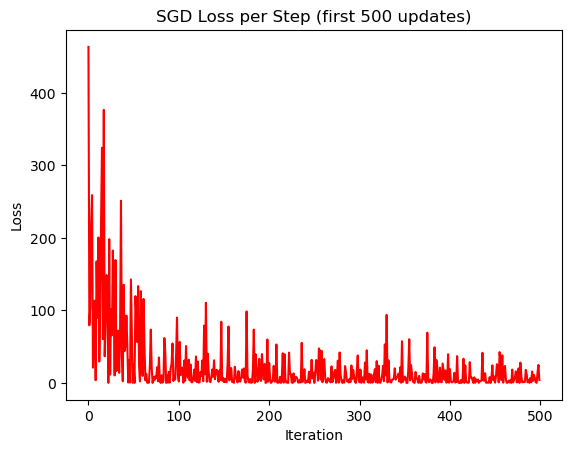

In [73]:
sgd_theta, losses = stochastic_gradient_descent(X_b, y, n_epochs=50, learning_rate=0.01)

# In loss cho 500 bước đầu
x_axis = list(range(500))
plt.plot(x_axis, losses[:500], color="r")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("SGD Loss per Step (first 500 updates)")
plt.show()

## 2. Mini-batch Gradient Descent